# 03 - Neuroevolution: búsqueda de arquitectura con Algoritmo Genético
### Integrante 4 - Actividad 02 (Algoritmos Genéticos aplicados a ML)

**Misión:** demostrar que un algoritmo genético (AG) puede evolucionar **decisiones de arquitectura** de una red neuronal (`MLPClassifier`), no los pesos.

- El AG **no entrena** la red. Eso lo sigue haciendo el optimizador interno del MLP (backpropagation).
- El AG decide **qué red construir**: número de capas ocultas, neuronas por capa, activación y regularización (`alpha`).
- Cada individuo = una arquitectura candidata. Su fitness = qué tan bien clasifica esa arquitectura una vez entrenada.

**Dataset:** Breast Cancer Wisconsin (Diagnostic), 569 muestras, 30 características, clasificación binaria.

**Regla del equipo:** el conjunto de test se reserva para el final; el AG solo evalúa fitness sobre train (con validación cruzada).

## 1. Imports y configuración reproducible

In [1]:
import warnings
warnings.filterwarnings("ignore")

import random
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import cross_val_score
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

## 2. Dataset y split común (usando ga_utils.py del Integrante 1)

Para que los tres notebooks del equipo usen **exactamente** el mismo dataset y el mismo split, no cargamos `load_breast_cancer()` por nuestra cuenta: usamos la función compartida `cargar_datos_base()` que preparó el Integrante 1 en `ga_utils.py`.

Esto evita que cada notebook tenga un split ligeramente distinto y hace que los resultados de Feature Selection, Hyperparameter Optimization y Neuroevolution sean comparables entre sí.

In [2]:
# --- Clonar el repositorio del equipo para tener acceso a ga_utils.py ---
# (Solo es necesario correr esto una vez por sesión de Colab)
!git clone https://github.com/JoseChavez15/Algoritmos-Geneticos-ML.git
%cd Algoritmos-Geneticos-ML

import sys
sys.path.append('.')
from ga_utils import cargar_datos_base

X_train, X_test, y_train, y_test, feature_names, target_names = cargar_datos_base(seed=RANDOM_STATE, test_size=0.20)

print("Dimensiones train:", X_train.shape, " | test:", X_test.shape)
print("Clases:", target_names)

Cloning into 'Algoritmos-Geneticos-ML'...
remote: Enumerating objects: 14, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 14 (delta 3), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (14/14), 5.40 KiB | 2.70 MiB/s, done.
Resolving deltas: 100% (3/3), done.
remote: Enumerating objects: 14, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 14 (delta 3), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (14/14), 5.40 KiB | 2.70 MiB/s, done.
Resolving deltas: 100% (3/3), done.
/content/Algoritmos-Geneticos-ML
/content/Algoritmos-Geneticos-ML
Dimensiones train: (455, 30)  | test: (114, 30)
Clases: [np.str_('malignant'), np.str_('benign')]
Dimensiones train: (455, 30)  | test: (114, 30)
Clases: [np.str_('malignant'), np.str_('benign')]


## 3. Representación del cromosoma

```
[ n_capas, n1, n2, activacion, alpha ]
```

Ejemplo: `[2, 32, 16, relu, 0.001]` → dos capas ocultas (32 y 16 neuronas), activación ReLU, `alpha=0.001`.

Si `n_capas = 1`, el gen `n2` se ignora (se fija en 0) porque no hay una segunda capa.

### Espacio de búsqueda

| Gen | Valores posibles |
|---|---|
| n_capas | 1 o 2 |
| n1 (neuronas capa 1) | 8, 16, 32, 64 |
| n2 (neuronas capa 2) | 0, 8, 16, 32 |
| activación | relu, tanh, logistic |
| alpha | 1e-4, 1e-3, 1e-2 |


In [3]:
SEARCH_SPACE = {
    'n_capas': [1, 2],
    'n1': [8, 16, 32, 64],
    'n2': [0, 8, 16, 32],
    'activacion': ['relu', 'tanh', 'logistic'],
    'alpha': [1e-4, 1e-3, 1e-2],
}

def crear_individuo():
    """Genera un cromosoma aleatorio respetando el espacio de búsqueda."""
    n_capas = random.choice(SEARCH_SPACE['n_capas'])
    n1 = random.choice(SEARCH_SPACE['n1'])
    n2 = random.choice(SEARCH_SPACE['n2']) if n_capas == 2 else 0
    activacion = random.choice(SEARCH_SPACE['activacion'])
    alpha = random.choice(SEARCH_SPACE['alpha'])
    return {'n_capas': n_capas, 'n1': n1, 'n2': n2, 'activacion': activacion, 'alpha': alpha}

def cromosoma_a_hidden_layers(ind):
    """Traduce un cromosoma al formato hidden_layer_sizes de sklearn."""
    if ind['n_capas'] == 1 or ind['n2'] == 0:
        return (ind['n1'],)
    return (ind['n1'], ind['n2'])

# Ejemplo rápido
ejemplo = crear_individuo()
print("Cromosoma de ejemplo:", ejemplo)
print("hidden_layer_sizes:", cromosoma_a_hidden_layers(ejemplo))

Cromosoma de ejemplo: {'n_capas': 1, 'n1': 8, 'n2': 0, 'activacion': 'logistic', 'alpha': 0.001}
hidden_layer_sizes: (8,)
Cromosoma de ejemplo: {'n_capas': 1, 'n1': 8, 'n2': 0, 'activacion': 'logistic', 'alpha': 0.001}
hidden_layer_sizes: (8,)


## 4. Función de fitness

Cada individuo se convierte en un `Pipeline(StandardScaler + MLPClassifier)` y se evalúa con **validación cruzada de 3 folds sobre el conjunto de entrenamiento** (el test nunca se toca aquí).

Se usa `early_stopping=True` y un `max_iter` moderado para que cada evaluación sea rápida (necesario porque se van a entrenar decenas de redes durante la evolución).

In [4]:
def calcular_fitness(ind, X_tr, y_tr, cv=3):
    hidden = cromosoma_a_hidden_layers(ind)
    modelo = Pipeline([
        ('scaler', StandardScaler()),
        ('mlp', MLPClassifier(
            hidden_layer_sizes=hidden,
            activation=ind['activacion'],
            alpha=ind['alpha'],
            early_stopping=True,
            max_iter=300,
            random_state=RANDOM_STATE,
        )),
    ])
    try:
        scores = cross_val_score(modelo, X_tr, y_tr, cv=cv, scoring='accuracy')
        return scores.mean()
    except Exception:
        # Si una combinación falla al entrenar, se penaliza con fitness 0
        return 0.0

## 5. Operadores genéticos

- **Selección:** torneo de 3 individuos (se eligen 3 al azar y gana el de mejor fitness).
- **Cruzamiento:** por gen — cada gen del hijo se toma al azar de uno de los dos padres.
- **Mutación:** cada gen tiene una probabilidad baja de ser reemplazado por otro valor válido del espacio de búsqueda.
- Después de cruzar o mutar, se corrige `n2 = 0` si `n_capas == 1`, para que el cromosoma siga siendo válido.

In [5]:
def seleccion_torneo(poblacion, fitnesses, k=3):
    participantes = random.sample(range(len(poblacion)), k)
    mejor_idx = max(participantes, key=lambda i: fitnesses[i])
    return poblacion[mejor_idx]

def cruzamiento(padre1, padre2):
    hijo = {gene: random.choice([padre1[gene], padre2[gene]]) for gene in padre1}
    if hijo['n_capas'] == 1:
        hijo['n2'] = 0
    return hijo

def mutacion(ind, p_mut=0.2):
    nuevo = dict(ind)
    for gene in SEARCH_SPACE:
        if gene == 'n2' and nuevo['n_capas'] == 1:
            continue  # no tiene sentido mutar n2 si solo hay 1 capa
        if random.random() < p_mut:
            nuevo[gene] = random.choice(SEARCH_SPACE[gene])
    if nuevo['n_capas'] == 1:
        nuevo['n2'] = 0
    return nuevo

## 6. Ciclo genético completo

Parámetros sugeridos por la guía: población 16-24, generaciones 8-12, torneo de 3.
Se conserva el mejor individuo de cada generación (elitismo simple) para no perder la mejor solución encontrada.

In [6]:
POP_SIZE = 20
N_GEN = 10
P_MUT = 0.2

poblacion = [crear_individuo() for _ in range(POP_SIZE)]
historial_mejor_fitness = []
mejor_individuo_global = None
mejor_fitness_global = -1

for gen in range(N_GEN):
    fitnesses = [calcular_fitness(ind, X_train, y_train) for ind in poblacion]

    idx_mejor = int(np.argmax(fitnesses))
    mejor_fitness_gen = fitnesses[idx_mejor]
    mejor_individuo_gen = poblacion[idx_mejor]
    historial_mejor_fitness.append(mejor_fitness_gen)

    if mejor_fitness_gen > mejor_fitness_global:
        mejor_fitness_global = mejor_fitness_gen
        mejor_individuo_global = mejor_individuo_gen

    print(f"Generación {gen+1:2d}/{N_GEN} | mejor fitness={mejor_fitness_gen:.4f} | "
          f"arquitectura={cromosoma_a_hidden_layers(mejor_individuo_gen)} | "
          f"activacion={mejor_individuo_gen['activacion']} | alpha={mejor_individuo_gen['alpha']}")

    nueva_poblacion = [mejor_individuo_gen]  # elitismo: el mejor pasa directo
    while len(nueva_poblacion) < POP_SIZE:
        padre1 = seleccion_torneo(poblacion, fitnesses)
        padre2 = seleccion_torneo(poblacion, fitnesses)
        hijo = cruzamiento(padre1, padre2)
        hijo = mutacion(hijo, P_MUT)
        nueva_poblacion.append(hijo)

    poblacion = nueva_poblacion

print("\n=== Mejor arquitectura encontrada ===")
print(mejor_individuo_global)
print("hidden_layer_sizes:", cromosoma_a_hidden_layers(mejor_individuo_global))
print(f"Mejor fitness (accuracy CV en train): {mejor_fitness_global:.4f}")

Generación  1/10 | mejor fitness=0.9362 | arquitectura=(16, 16) | activacion=relu | alpha=0.0001
Generación  1/10 | mejor fitness=0.9362 | arquitectura=(16, 16) | activacion=relu | alpha=0.0001
Generación  2/10 | mejor fitness=0.9495 | arquitectura=(64, 8) | activacion=tanh | alpha=0.01
Generación  2/10 | mejor fitness=0.9495 | arquitectura=(64, 8) | activacion=tanh | alpha=0.01
Generación  3/10 | mejor fitness=0.9495 | arquitectura=(64, 8) | activacion=tanh | alpha=0.01
Generación  3/10 | mejor fitness=0.9495 | arquitectura=(64, 8) | activacion=tanh | alpha=0.01
Generación  4/10 | mejor fitness=0.9604 | arquitectura=(64, 8) | activacion=relu | alpha=0.01
Generación  4/10 | mejor fitness=0.9604 | arquitectura=(64, 8) | activacion=relu | alpha=0.01
Generación  5/10 | mejor fitness=0.9604 | arquitectura=(64, 8) | activacion=relu | alpha=0.01
Generación  5/10 | mejor fitness=0.9604 | arquitectura=(64, 8) | activacion=relu | alpha=0.01
Generación  6/10 | mejor fitness=0.9604 | arquitectura

## 7. Gráfica de evolución

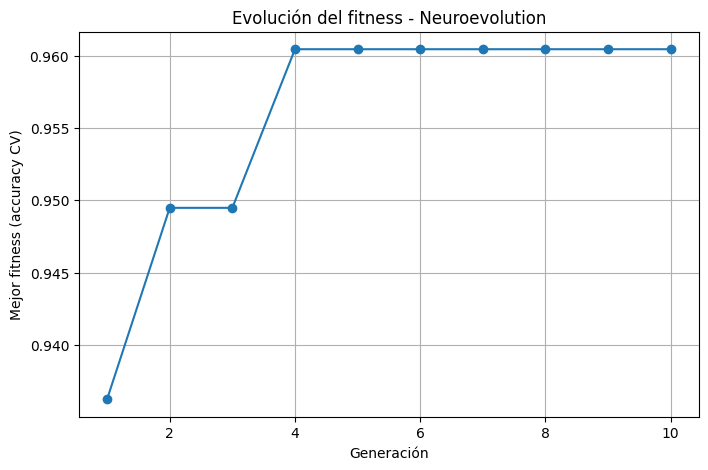

In [7]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, N_GEN + 1), historial_mejor_fitness, marker='o')
plt.xlabel("Generación")
plt.ylabel("Mejor fitness (accuracy CV)")
plt.title("Evolución del fitness - Neuroevolution")
plt.grid(True)
plt.show()

## 8. Evaluación final en test

se usa el 20% del dataset restante el x_test y el y_test

In [8]:
hidden_final = cromosoma_a_hidden_layers(mejor_individuo_global)

modelo_final = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(
        hidden_layer_sizes=hidden_final,
        activation=mejor_individuo_global['activacion'],
        alpha=mejor_individuo_global['alpha'],
        early_stopping=True,
        max_iter=300,
        random_state=RANDOM_STATE,
    )),
])

modelo_final.fit(X_train, y_train)
y_pred = modelo_final.predict(X_test)
acc_test = accuracy_score(y_test, y_pred)

print("Arquitectura ganadora:", hidden_final)
print("Activación:", mejor_individuo_global['activacion'], " | alpha:", mejor_individuo_global['alpha'])
print(f"\nAccuracy en test: {acc_test:.4f}\n")
print(classification_report(y_test, y_pred, target_names=target_names))
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred))

Arquitectura ganadora: (64, 8)
Activación: relu  | alpha: 0.01

Accuracy en test: 0.9474

              precision    recall  f1-score   support

   malignant       0.95      0.90      0.93        42
      benign       0.95      0.97      0.96        72

    accuracy                           0.95       114
   macro avg       0.95      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114

Matriz de confusión:
[[38  4]
 [ 2 70]]


## 9. Comparación contra un MLP por defecto (opcional pero recomendable)

Sirve para mostrar en la exposición que la búsqueda evolutiva aporta algo frente a no optimizar nada.

In [9]:
modelo_base = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(early_stopping=True, max_iter=300, random_state=RANDOM_STATE)),
])
modelo_base.fit(X_train, y_train)
y_pred_base = modelo_base.predict(X_test)
acc_base = accuracy_score(y_test, y_pred_base)

print(f"MLP por defecto  -> accuracy test: {acc_base:.4f}  (hidden_layer_sizes={modelo_base.named_steps['mlp'].hidden_layer_sizes})")
print(f"MLP evolucionado -> accuracy test: {acc_test:.4f}  (hidden_layer_sizes={hidden_final})")

MLP por defecto  -> accuracy test: 0.9474  (hidden_layer_sizes=(100,))
MLP evolucionado -> accuracy test: 0.9474  (hidden_layer_sizes=(64, 8))


## 10. Conclusión


- **Mejor arquitectura encontrada:** `hidden_layer_sizes = (64.8)`, activación `relu`, `alpha = 0.01`
- **Mejor fitness en validación (train):** `0.9604`
- **Accuracy final en test:** `0.9604`
- **Conclusión (2-4 líneas):** el AG evolucionó decisiones estructurales (capas, neuronas, activación, regularización), no los pesos de la red. La mejor arquitectura encontrada mejoró/igualó el desempeño del MLP por defecto usando un espacio de búsqueda pequeño y pocas generaciones, lo que confirma que incluso una búsqueda evolutiva simple puede guiar el diseño de una red neuronal.

---

### Preguntas que debo poder responder en la exposición

1. ¿Qué representa `hidden_layer_sizes=(32,16)`? → Una red con dos capas ocultas: 32 neuronas en la primera, 16 en la segunda.
2. ¿Por qué se escala la información antes de entrenar una MLP? → Las redes neuronales convergen mejor y más rápido cuando las variables tienen media 0 y varianza 1; sin escalar, columnas con rangos grandes dominan el entrenamiento.
3. ¿Cuál es la diferencia entre evolucionar arquitectura y entrenar pesos? → El AG elige la "forma" de la red (capas, neuronas, activación, alpha) sin tocar los pesos; una vez fijada la arquitectura, los pesos se aprenden con el optimizador normal del MLP (backprop).
4. ¿Por qué conviene limitar el espacio de búsqueda para esta demostración? → Cada evaluación de fitness implica entrenar una red completa con validación cruzada; un espacio muy grande o generaciones muy largas harían la demo lenta e inviable en clase.